In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # adjust as needed

import gc
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import jax
import jax.numpy as jnp

import keras
import keras.ops as ops
import keras_hub
# Use bfloat16 throughout: halves the memory footprint of the model with
# negligible impact on quality for this kind of fine-tuning.
keras.config.set_dtype_policy("bfloat16")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 90

2026-06-01 09:09:51.005295: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780304991.021232 3352445 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780304991.026093 3352445 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780304991.042180 3352445 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780304991.042194 3352445 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780304991.042196 3352445 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Session 7: Leveraging existing models

## Overview and objectives

In sessions 1–6 we have built machine-learning models *from scratch*: we chose architectures, designed training loops, and tuned thousands to a few hundred thousand parameters. That workflow is appropriate for problems where:

- A reasonable amount of task-specific data is available.
- The output is structured (a class, a regression target, a fixed-length vector).
- We can afford to train end-to-end.

But the AI landscape is shifting toward the reuse of pre-trained general-purpose models. There are two main reasons for this:
 - Models are becoming absolutely **huge** (up to trillions of parameters).
 - Most researchers/developers **don't have the resources** (data, computing power) to train this kind of models.

The so-called **foundation models** (large neural networks pre-trained on internet-scale data) already encode an enormous amount of general knowledge. For many problems, the right question is no longer "how do I train a model from scratch?" but **"how do I adapt an existing model with as little data and compute as possible?"**.

This session covers the three most important strategies for leveraging foundation models:

1. **Direct use** of a pre-trained model (no training).
2. **Component reuse**: using individual pieces of a pre-trained model (e.g. tokenizers, embeddings) as building blocks.
3. **Parameter-efficient fine-tuning (PEFT)** with **LoRA**: adapting a billion-parameter model by training only a fraction of new parameters.

## What you will learn

By the end of this session, you should be able to:

1. **Load and run a state-of-the-art LLM locally** using KerasHub, in the same Keras 3 + JAX environment you have used throughout the course.
2. **Use individual components** of a foundation model (tokenizers, embeddings) for downstream tasks.
3. **Perform transfer-learning and fine-tuning** on mid-sized models for specific tasks.
4. **Understand the mathematics of LoRA**: why $W' = W_0 + BA$ with small rank $r$ is enough to adapt a pre-trained model, and what this implies for memory and compute.
5. **Implement LoRA fine-tuning** on the Gemma 2B model.
7. **Evaluate a fine-tuned LLM** qualitatively and quantitatively.

## 1. Directly using third-party models: [🤗 HuggingFace](https://huggingface.co/)

HuggingFace is a company that provides open-source tools, models, and a platform for machine learning development:

 - **Open-Source Machine Learning Tools**: Wide range of open-source libraries and tools, such as Transformers, which facilitate the development and deployment of machine learning models, particularly in natural language processing (NLP).
 - **Model Hub**: Vast repository of pre-trained models across various domains, allowing users to easily download, fine-tune, and integrate state-of-the-art models into their applications.
 - **Community and Collaboration**: Community of developers and researchers, offering platforms for collaboration, knowledge sharing, and contributions to machine learning advancements.
 - **APIs and Integrations**: APIs and integrations for deploying models as scalable services, enabling seamless use in production environments across different platforms.

⚠️ __Unfortunately, a network issue prevents us from using HuggingFace from the server.__

### 💡 KerasHub vs. HuggingFace. 
HuggingFace is the largest model hub in the ecosystem, with millions of models. [Keras-hub](https://keras.io/keras_hub/) is smaller but has two key advantages: 
 1. Every model is a native `keras.Model` that integrates seamlessly with the API we have used throughout the course
 2. The same code runs on JAX, TensorFlow, and PyTorch backends without modification.

In this session, we will use the **[Gemma 4](https://ai.google.dev/gemma/docs/get_started) model**, the latest open-source foundation model behind Google's [Gemini](https://gemini.google.com/) AI. Specifically, we'll use the [`Gemma 4 2B instruct`](https://www.kaggle.com/models/google/gemma-4/keras/gemma4_instruct_2b) version, which contains a total 5.1 billion parameters (2.3 billion active at inference). The model is already downloaded and extracted in a local path `/opt/tljh/common/gemma4_instruct_2b`:

In [2]:
gemma_lm = keras_hub.models.Gemma4CausalLM.from_preset("/opt/tljh/common/gemma4_instruct_2b")
gemma_lm.summary()

2026-06-01 09:10:08.542625: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1780305008.543891 3352445 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 27095 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:41:00.0, compute capability: 8.9
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Preprocessor: "gemma4_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma4_tokenizer_1 (Gemma4Tokenizer)                          │                      Vocab size: 262,144 │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_image_converter (Gemma4ImageConverter)                 │                       Image size: (1, 1) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_audio_converter (Gemma4AudioConverter)                 │                Audio shape: (3,000, 128) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_video_converter (Gemma4ImageConverter)                 │                       Image size: (1, 1) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_video_converter (ImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma4_causal_lm_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ audio_indices (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mask (InputLayer)       │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mel (InputLayer)        │ (None, None, None, 128)   │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mel_mask (InputLayer)   │ (None, None, None)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pixel_position_ids            │ (None, None, None, 2)     │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pixel_values (InputLayer)     │ (None, None, None, None)  │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ position_ids (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vision_indices (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vision_mask (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma4_backbone_1             │ (None, None, 1536)        │   5,104,298,467 │ audio_indices[0][0],       │
│ (Gemma4Backbone)              │                           │                 │ audio_mask[0][0],          │
│                               │                           │                 │ audio_mel[0][0],           │
│                               │                           │                 │ audio_mel_mask[0][0],      │
│                               │                           │                 │ padding_mask[0][0],        │
│                               │                           │                 │ pixel_position_ids[0][0],  │
│                               │                           │                 │ pixel_values[0][0],        │
│                               │                           │                 │ position_ids[0][0],        │
│                               │                           │                 │ token_ids[0][0],           │
│                               │                           │                 │ vision_indices[0][0],      │
│                               │                           │               

 Total params: 5,104,298,467 (10.08 GB)

 Trainable params: 5,104,186,912 (10.08 GB)

 Non-trainable params: 111,555 (434.82 KB)

 A few things worth noting from the summary:

- **5.1 billion parameters (2.3 active)**, occupying about **10 GB** in `bfloat16` (twice that in `float32`).
- The model is just another `keras.Model`. We can call `.generate()`, `.fit()`, `.predict()`, set callbacks, save and load it. Everything we have learned in previous sessions applies.
- The architecture has two top-level components: a **backbone** (the transformer stack) and a **token embedding** (which maps token IDs to vectors and back). It also a multi-modal model, including layers for **image, audio and video** processing.

Let's quickly inspect the `backbone`:

In [3]:
gemma_lm.backbone.summary()

Model: "gemma4_backbone_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_mel_mask      │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_position_ids  │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 2)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_values        │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, None)       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_mel           │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, None,      │          0 │ audio_mel_mask[0… │
│                     │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gemma4_vision_enco… │ (None, None,      │ 168,544,7… │ pixel_position_i… │
│ (Gemma4VisionEncod… │ None, 1536)       │            │ pixel_values[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vision_mask         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gemma4_audio_encod… │ (None, None,      │ 307,184,3… │ audio_mel[0][0],  │
│ (Gemma4AudioEncode… │ None, 1536)       │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, None,      │          0 │ gemma4_vision_en… │
│                     │ None, 1536)       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, None,      │ 402,653,1… │ token_ids[0][0]   │
│ (ReversibleEmbeddi… │ 262144)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vision_indices      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_3 (Cast)       │ (None, None)      │          0 │ vision_mask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, None)      │          0 │ token_ids[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, None,      │          0 │ gemma4_audio_enc… │
│ (Multiply)          │ None, 1536)       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interleave_embeddi… │ (None, None,      │          0 │ multiply[0][0],   │
│ (Gemma4InterleaveE… │ 1536)             │            │ token_embedding[… │
│                     │                   │            │ vision_indices[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_indices       │ (None, None)      │          0 │ -               

 Total params: 5,104,298,467 (10.08 GB)

 Trainable params: 5,104,186,912 (10.08 GB)

 Non-trainable params: 111,555 (434.82 KB)

 - We can directly use the `generate` method of the model to generate text that follows a specific prompt, following the "next-token-prediction" paradigm:

In [4]:
out = gemma_lm.generate("Keras 3.0 is a", max_length=200)
print(out)

Keras 3.0 is a significant update, bringing significant improvements in performance, flexibility, and compatibility. Here's a breakdown of what's new and why it matters:

**1. Unified Backend (XLA, TensorFlow, PyTorch)**

* **What's New:** Keras 3.0 introduces a unified backend system. You can now choose between different execution backends like XLA (for high-performance compilation), TensorFlow, or PyTorch.
* **Why it Matters:** This allows Keras models to run on the backend that is best suited for your specific needs.
    * **Performance:** If you need maximum speed, you can leverage XLA for optimized execution.
    * **Ecosystem Access:** You can seamlessly integrate with existing TensorFlow or PyTorch models and datasets without rewriting your entire model architecture.
    * **Flexibility:** You are no longer locked into a single framework.

**2. Improved Interoperability**




 - Even if LLM are highly stochastic, by default Keras configures the generation so it always takes the token with highest probability ([greedy](https://keras.io/keras_hub/api/samplers/greedy_sampler/)). This causes a deterministic effect in the generation:

In [5]:
out2 = gemma_lm.generate("Keras 3.0 is a", max_length=200)
print(out==out2)

True


 - We can add some variability by modifying how sampling is done on inference. We achieve this by compiling the model with a different [`sampler`](https://keras.io/keras_hub/api/samplers/):

In [6]:
gemma_lm.compile(sampler=keras_hub.samplers.TopKSampler(k=40, temperature=0.7))
print(gemma_lm.generate("Keras 3.0 is a", max_length=200))

Keras 3.0 is a major update that brings significant improvements, especially in terms of backend compatibility (TensorFlow, PyTorch, JAX) and a more unified API.

Here is a breakdown of what this means for users:

### 1. Unified API (The Major Simplification)
* **What changed:** Keras 3.0 consolidates the way you write models. Previously, users often had to manage separate Keras implementations for TensorFlow, PyTorch, etc., which led to boilerplate code when switching backends.
* **User Benefit:** You write your model definition *once*, and Keras handles the translation to the appropriate backend code. This makes switching between TensorFlow and PyTorch much cleaner and reduces code duplication.

### 2. Backend Flexibility and Performance
* **What changed:** Keras 3 is built on a "backend-agnostic" design. The same Keras model definition can run natively on TensorFlow, PyTorch, or


----

 - More interesting, since we have downloaded the `instruct` model, we can give it **direct instructions**. Gemma Instruct expects prompts in a specific chat format using the special tokens `<|turn>user`, `<turn|>`, `<|turn>model`. Let's define some helpers to clean the outputs and facilitate interaction:

In [7]:
from IPython.display import Markdown, display

def strip_prompt(output, prompt):
    if isinstance(output, list):
        output = output[0]
    if output.startswith(prompt):
        output = output[len(prompt) :]
    marker = "<|turn>model\n"
    index = output.rfind(marker)
    if index != -1:
        output = output[index+len(marker):]
    eidx = output.rfind('<turn|>')
    if eidx != -1:
        return output[:eidx]
    return output

def display_model_response(text, title="Gemma response", language=None):
    cleaned = re.sub(r"<(?:turn\||channel\|)>", "", text).strip()
    display(Markdown(f"> **{title}**"))
    if language:
        display(Markdown(f"```{language}\n{cleaned}\n```"))
        return

    def demote_heading(match):
        hashes = match.group(1)
        return "#" * min(len(hashes) + 1, 6) + " "

    cleaned = re.sub(r"^(#{1,5})\s+", demote_heading, cleaned, flags=re.MULTILINE)
    display(Markdown(cleaned))

def instruct_gemma(gemma_lm, text_prompt, max_length=512):
    prompt = f'<|turn>user\n{text_prompt}<turn|>\n<|turn>model'
    return strip_prompt(gemma_lm.generate({"prompts":[prompt]}, max_length=max_length), prompt)


def ask_gemma(text_prompt, max_length=512):
    display_model_response(instruct_gemma(gemma_lm, text_prompt, max_length))

In [8]:
ask_gemma('Give me a nice brownie recipe', max_length=500)

> **Gemma response**

here is a fantastic, classic, and incredibly fudgy brownie recipe that most people adore! It uses melted butter for that rich flavor and a good balance of chocolate and sweetness.

### The Ultimate Fudgy Brownie Recipe

This recipe yields rich, dense, and intensely chocolatey brownies with a crackly top.

**Yields:** 16 brownies
**Prep time:** 15 minutes
**Bake time:** 30-35 minutes

#### Ingredients

**For the Brownies:**

* **1 cup (2 sticks or 226g) unsalted butter**, melted
* **1 cup (200g) granulated sugar**
* **1 cup (200g) packed light brown sugar**
* **3 large eggs**
* **1 teaspoon vanilla extract**
* **2 cups (250g) all-purpose flour**
* **¾ cup (65g) unsweetened cocoa powder** (use high quality for best flavor!)
* **½ teaspoon salt**
* **1 cup (170g) chocolate chips** (or chunks, for extra goodness!)

**Optional Mix-ins (Choose one or more):**
* Walnuts or pecans (½ cup, roughly chopped)
* Mini chocolate chips
* Sea salt flakes (for sprinkling on top)

#### Instructions

**1. Preheat and Prep:**
* Preheat your oven to **350°F (175°C)**.
* Grease and line an 8x8 inch baking pan with parchment paper, leaving an overhang on the sides. This makes lifting the brownies out much easier!

**2. Melt the Butter & Sugar:**
* In a large, heatproof bowl, melt the butter in the microwave or over a double boiler.
* Once melted, whisk in both the granulated sugar and brown sugar until well combined and smooth.

**3. Add Wet Ingredients:**
* Whisk in the eggs one at a time, ensuring each is fully incorporated before adding the next.
* Stir in the vanilla extract.

**4. Combine Dry Ingredients:**
* In a separate bowl, whisk together the flour, cocoa powder, and salt until thoroughly combined.

**5. Combine Wet and Dry:**
* Gradually add the dry ingredient mixture to the wet ingredient mixture

----

 - However, we can see that all instructions are treated as independent, and that the model provides no *conversational memory*. In general, LLM don't save any state about past queries/prompts.

In [9]:
ask_gemma("I don't have vanilla extract, please update the recipe with another ingredient")

> **Gemma response**

please provide the recipe you are referring to! I need the original recipe to suggest a suitable substitute for vanilla extract. 😊

### Multi-modal interaction

 - Gemma 4 supports image understanding directly through `generate()`. A simple captioning prompt is a good way to verify multimodal input handling before moving on to more structured visual tasks.

> **Gemma response**

This is an image of two tabby cats lying on a bright pink surface, likely a blanket or soft fabric.

Here's a detailed description:

*   **Subjects:** There are two cats.
    *   The cat on the left has a striped, brownish-gray tabby coat and is lying down, looking towards the camera.
    *   The cat on the right is also a tabby, possibly with more orange/ginger tones, and is stretched out, appearing relaxed or perhaps slightly drowsy.
*   **Setting/Background:** The cats are resting on a vibrant **pink** surface that dominates the foreground and background. The fabric appears soft and plush.
*   **Objects:**
    *   Near the cat on the left, there is a white object lying on the pink surface, which looks like a remote control or a similar electronic device with buttons.
    *   Near the cat on the right, there is a light-colored, possibly blue and white, object with buttons, resembling a small remote or a toy.
*   **Mood:** The overall mood of the image is cozy, relaxed, and domestic.

In summary, the image captures a peaceful moment of two tabby cats lounging on a pink textile.

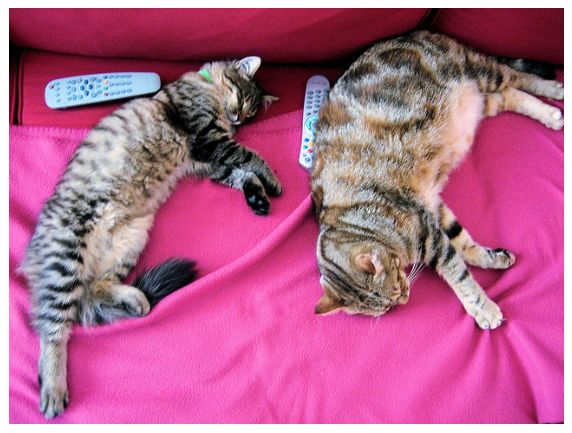

In [10]:
from PIL import Image

PROMPT_IMAGE = (
    "<|turn>user\n"
    "<|image|>\n"
    "Describe what you see in this image<turn|>\n"
    "<|turn>model\n"
)

image = Image.open('assets/000000039769.jpg').convert("RGB")
plt.imshow(image)
plt.axis('off')

image_output = gemma_lm.generate(
    {"prompts": [PROMPT_IMAGE], "images": [image]},
    max_length=2048,
)

display_model_response(strip_prompt(image_output, PROMPT_IMAGE))

#### Object detection and localization

Gemma 4 can localize objects by returning structured JSON alongside natural- language output. In practice, the model often produces a short explanation before the JSON payload, so it is useful to parse the fenced block explicitly.

In the following code snippet, the model identifies cats in the image and the JSON is visualized (normalized 0-1000 coordinates).

> **Gemma response**

```json
[
  {"box_2d": [104, 13, 986, 494], "label": "cat"},
  {"box_2d": [48, 522, 774, 995], "label": "cat"}
]
```

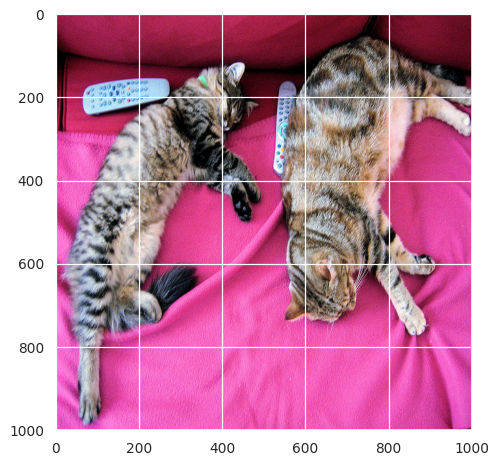

In [11]:
PROMPT_DETECTION = (
    "<|turn>user\n"
    "<|image|>\n"
    "Identify every cat in this image. First give one short sentence, then\n"
    "return a JSON array inside a ```json``` block. Each item must contain\n"
    "<|turn>model\n"
)
detection_output = gemma_lm.generate(
    {"prompts": [PROMPT_DETECTION], "images": [image]},
    max_length=2048,
)
raw_detection_text = strip_prompt(detection_output, PROMPT_DETECTION)
display_model_response(raw_detection_text)
plt.imshow(image,  extent=[0, 1000, 1000, 0])

## 2. Reusing pre-trained components

A trained LLM is not a single monolithic object — it is composed of pieces that can be used independently. The two most useful are:

1. The **tokenizer**, which converts strings ↔ integer token IDs.
2. The **token embedding**, which maps token IDs to high-dimensional vectors that capture semantic meaning.

### 2.1 Tokenizers

A tokenizer encodes text into a sequence of integers from a fixed vocabulary. Gemma's tokenizer has 256 000 entries and it can handle any Unicode input.

In [12]:
tokenizer = gemma_lm.preprocessor.tokenizer

# Basic tokenization
sentence = "The quick brown fox jumped."
ids = tokenizer(sentence)
print(f"Token IDs ({len(ids)} tokens): {ids}")

# Roundtrip
print(f"Detokenized: {tokenizer.detokenize(ids)}")

# Per-token view
for tid in ids:
    print(f"  {int(tid):>7}  →  {repr(tokenizer.detokenize([tid]))}")

#Tokenization can be also done in batches:
print(tokenizer(["The quick brown fox jumped.", "The fox slept."]))

Token IDs (6 tokens): [   818   3823   8864  37423  32694 236761]
Detokenized: The quick brown fox jumped.
      818  →  'The'
     3823  →  ' quick'
     8864  →  ' brown'
    37423  →  ' fox'
    32694  →  ' jumped'
   236761  →  '.'
[[818, 3823, 8864, 37423, 32694, 236761], [818, 37423, 57120, 236761]]


### 2.2 Embeddings as semantic vectors

Another, more interesting use case is exploiting the `Embeddings` of the model:
 - Embeddings can be seen as functions that **convert a token to a vector in a high-dimensional space**.
 - This high-dimensional space preserves the **semantic meaning** the model gives to each token.
 - Extremely useful for many natural language processing tasks (classification, sentiment analysis, etc.)

The token embedding is a $V \times d$ matrix, where $V$ is the vocabulary size and $d$ is the embedding dimension (1536 for Gemma 2B). Each row is a learned vector that captures the **semantic meaning of a token**. Tokens with similar meanings tend to have embeddings with high cosine similarity.

In [13]:
from optax.losses import cosine_similarity
sentences = ["The quick brown fox jumped and got tired", 
             "My dog ran through the yard until feeling exhausted", 
             "I don't want to be aware of your love feelings"]

tokenizations = [tokenizer(s) for s in sentences]
embeddings = [gemma_lm.backbone.token_embedding(tk) for tk in tokenizations]
similarities = {}
for i in range(len(sentences)):
    for j in range(len(tokenizations[i])):
        ref = embeddings[i][j]
        for k in range(i+1, len(sentences)):            
            for n in range(len(tokenizations[k])):
                similarities[(tokenizer.detokenize([tokenizations[i][j]]), 
                              tokenizer.detokenize([tokenizations[k][n]]))] = cosine_similarity(ref, embeddings[k][n])
sorted_similarities = dict(sorted(similarities.items(), key=lambda item: item[1], reverse=True))
display(list(sorted_similarities.items())[:15])

[((' feeling', ' feelings'), Array(0.648438, dtype=bfloat16)),
 ((' tired', ' exhausted'), Array(0.539062, dtype=bfloat16)),
 (('The', ' the'), Array(0.419922, dtype=bfloat16)),
 ((' the', ' your'), Array(0.294922, dtype=bfloat16)),
 ((' the', ' to'), Array(0.287109, dtype=bfloat16)),
 (('The', 'My'), Array(0.285156, dtype=bfloat16)),
 ((' fox', ' dog'), Array(0.28125, dtype=bfloat16)),
 ((' and', ' of'), Array(0.279297, dtype=bfloat16)),
 ((' and', ' to'), Array(0.273438, dtype=bfloat16)),
 (('My', 'I'), Array(0.269531, dtype=bfloat16)),
 (('My', ' your'), Array(0.269531, dtype=bfloat16)),
 ((' the', ' of'), Array(0.267578, dtype=bfloat16)),
 ((' and', ' the'), Array(0.244141, dtype=bfloat16)),
 (('The', 'I'), Array(0.234375, dtype=bfloat16)),
 ((' through', ' to'), Array(0.216797, dtype=bfloat16))]

 - We may aggregate token semantic similarities at the level sentence, and do a very basic clustering by topic:

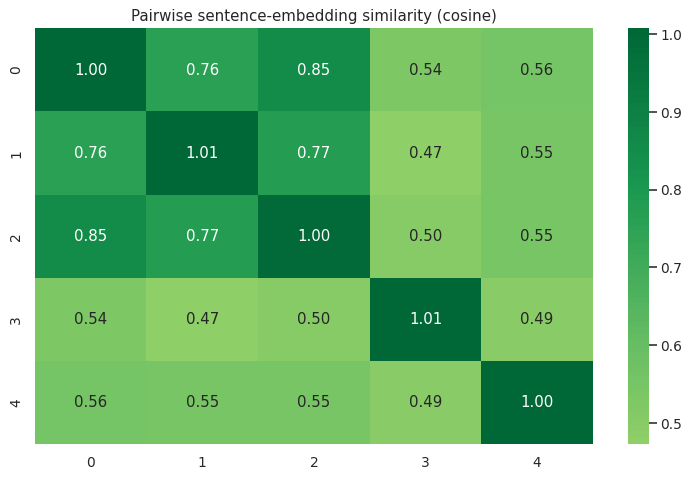

In [14]:
# Some sentences on different topics, with a very specific group on cardiac phenomena visible on the ECG.
sentences = [
    "A regular sinus rhythm with normal P wave and narrow QRS.",
    "A wide bizarre QRS complex without any preceding P wave.",
    "A premature beat with abnormal P wave but normal QRS width.",
    "Add salt and butter until golden brown.",
    "The string quartet performed a Beethoven sonata at the concert."
]

def embed_sentence(sentence):
    """Return the mean embedding of a sentence's tokens."""
    ids = tokenizer(sentence)
    token_embeddings = gemma_lm.backbone.token_embedding(jnp.array(ids))
    # Mean-pool over tokens to get a fixed-size sentence vector
    return jnp.mean(token_embeddings, axis=0)

embeddings = [embed_sentence(s) for s in sentences]

# Pairwise cosine similarities
sim_matrix = np.zeros((len(sentences), len(sentences)))
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        # cosine_similarity in optax returns 1 - cos_sim by convention; we negate to get true similarity
        sim_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])

sim_df = pd.DataFrame(sim_matrix)
sns.heatmap(sim_df, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title("Pairwise sentence-embedding similarity (cosine)")
plt.show()

In [ ]:
#Restart the kernel
import os
os._exit(00)

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"
#os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

import keras
import keras.ops as ops
import keras_hub

import gc
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## 3. Transfer learning and fine tuning

Transfer learning consists of **taking features learned on one problem, and leveraging them on a new, similar problem**.
 - Usually helps in tasks where your dataset has too little data to train a full-scale model from scratch.

Conceptually, transfer learning involves:

 1. Take layers from a previously trained model.
 2. Freeze them, so as to avoid destroying any of the information they contain during future training rounds.
 3. Add some new, trainable layers on top of the frozen layers. They will learn to turn the old features into predictions on a new dataset.
 4. Train the new layers on your dataset.

<img width="60%" src="https://www.researchgate.net/publication/354803048/figure/fig5/AS:1117058628620290@1643338939664/Representation-of-transfer-learning-between-two-neural-network-models_W640.jpg" style="margin:auto"/>

A last, optional step, is **fine-tuning**, which consists of unfreezing the entire model you obtained above and **re-training** it on the new data **with a very low learning rate**. This can potentially achieve meaningful improvements, by incrementally adapting the pretrained features to the new data.

The **key functionality** for transfer learning & fine-tuning in Keras is the `trainable` API:
 - `Layers` and `Models` have a `trainable` boolean attribute that can be changed programmatically.
 - Setting `layer.trainable` to `False` moves all the layer's weights from trainable to non-trainable. This is called "freezing" the layer.

### The typical transfer-learning workflow in Keras

#### 1. Instantiate a base model and load pre-trained weights into it.

```python
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(72, 72, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.
```

#### 2. Freeze all layers in the base model by setting `trainable = False`.


```python
base_model.trainable = False
```

#### 3. Create a new model on top of the output of one (or several) layers from the base model.

```python
inputs = keras.Input(shape=(72, 72, 3))
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning.
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
# A Dense classifier with a single unit (binary classification)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
```

#### 4. Train your new model on your new dataset.

```python
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.BinaryCrossentropy(),
              metrics=[keras.metrics.BinaryAccuracy()])
model.fit(new_dataset, epochs=5, callbacks=..., validation_data=...)
```

📌 __Example__: Based on an [Xception](https://keras.io/api/applications/xception/) network pre-trained on the ImageNet dataset, train a new one that learns how to distinguish cats from dogs on the CIFAR10 dataset.

 - First, we need to make sure that the target data fits the requirements of the base model. Checking the documentation of Xception, we see that:
     - It assumes an image size of 299x299 pixels. This size can be modified, but cannot be smaller than 71x71.
     - Each pixel has a value between -1 and +1 for each channel.

Since CIFAR10 is composed of 32x32 images, with each pixel in range [0-255], we need some preprocessing. Also, we have to remove all other classes apart from "cats" and "dogs":


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
#Cat is class 3, and dogs class 5 in the original dataset
idx_train = np.where(np.logical_or(y_train==3,y_train==5))[0]
idx_test = np.where(np.logical_or(y_test==3,y_test==5))[0]
x_train, y_train = x_train[idx_train], y_train[idx_train]
x_test, y_test = x_test[idx_test], y_test[idx_test]
#Convert labels to 0-1 (dogs-cats)
y_train = (y_train==3).astype(int)
y_test = (y_test==3).astype(int)
#Set fixed image size (72x72) and pixel range to [-1, 1]
resize = keras.layers.Resizing(72, 72, data_format='channels_last')
rescale = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)
x_train = resize(rescale(x_train))
x_test = resize(rescale(x_test))
print(x_train.shape)

(10000, 72, 72, 3)


Now let's built a model that follows the blueprint we've explained earlier.

👉 __Note that__:
 - We make sure to pass `training=False` when calling the base model, so that it runs in inference mode.

In [4]:
base_model = keras.applications.Xception(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(72, 72, 3),
    include_top=False) # Do not include the ImageNet classifier at the top.

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(72, 72, 3))

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # Regularize with dropout
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 72, 72, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 3, 3, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

 - Training of the top layer (the classifier for the new classes).

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()])

print("Fitting the top layer of the model")
model.fit(x_train, y_train, epochs=5, validation_split=0.2)

print("Test dataset evaluation after Transfer Learning")
y_pred = model.predict(x_test)>0.5
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1'])
display(cm_df)
display(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().round(2))

Fitting the top layer of the model
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - binary_accuracy: 0.7446 - loss: 0.5111 - val_binary_accuracy: 0.7700 - val_loss: 0.4707
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.7894 - loss: 0.4418 - val_binary_accuracy: 0.7825 - val_loss: 0.4526
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.7969 - loss: 0.4239 - val_binary_accuracy: 0.7890 - val_loss: 0.4501
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8079 - loss: 0.4119 - val_binary_accuracy: 0.7785 - val_loss: 0.4526
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8116 - loss: 0.4042 - val_binary_accuracy: 0.7880 - val_loss: 0.4737
Test dataset evaluation after Transfer Learning
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


,Pred 0,Pred 1
True 0,736,264
True 1,120,880


,precision,recall,f1-score,support
0,0.86,0.74,0.79,1000.00
1,0.77,0.88,0.82,1000.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.81,0.81,0.81,2000.00
weighted avg,0.81,0.81,0.81,2000.00


In [6]:
#We save the model weights after transfer learning, in case we want to try
#different rounds of fine-tuning.
tl_weights = model.get_weights()

### Fine-tuning

Once our model has converged on the new data, we can try to unfreeze all or part of the base model and retrain the whole model end-to-end with a very low learning rate.

This is an optional last step that can potentially give you incremental improvements. It could also **potentially lead to quick overfitting** -- keep that in mind.

It is critical to only do this step *after* the model with frozen layers has been trained to convergence:
 - Mixing randomly-initialized trainable layers with trainable layers that hold pre-trained features, the randomly-initialized layers will cause very large gradient updates during training.
 - This will destroy the pre-trained features.

It's also critical to use a very low learning rate at this stage, because we are training a much larger model than in the first round of training, on a dataset that is typically small.

As a result, we are at risk of overfitting very quickly if applying large weight updates. We only pursue **incremental adaption**

This is how to implement fine-tuning of the whole base model:

```python
# Unfreeze the base model
base_model.trainable = True

# It's important to recompile the model after changing the the `trainable`
# attribute of any inner layer, otherwise changes get ignored.
model.compile(optimizer=keras.optimizers.Adam(1e-5),  # Very low learning rate
              loss=keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[keras.metrics.BinaryAccuracy()])

# Train end-to-end. Be careful to stop before overfitting!
model.fit(new_xtrain, new_ytrain, epochs=10, callbacks=..., validation_split=...)
```

**Important note about `compile()` and `trainable`**

Calling `compile()` on a model is meant to "freeze" the behavior of that model.
 - The `trainable` attribute values at the time the model is compiled should be preserved throughout the lifetime of that model, until `compile` is called again.
 - If you change any `trainable` value, make sure to call `compile()` again!

In [7]:
# First, we restore the weights after transfer learning, so different fine-tuning rounds
# don't affect each other.
model.set_weights(tl_weights)
# Unfreeze the base_model. Note that it keeps running in inference mode
# since we passed `training=False` when creating it. This means that
# the batchnorm layers will not update their batch statistics.
# This prevents the batchnorm layers from undoing all the training
# we've done so far.
base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Low learning rate
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

print("Fitting the end-to-end model")
model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 72, 72, 3)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 3, 3, 2048)    │ 20,861,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting the end-to-end model
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - binary_accuracy: 0.7140 - loss: 0.5641 - val_binary_accuracy: 0.7800 - val_loss: 0.4984
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.8071 - loss: 0.4299 - val_binary_accuracy: 0.7955 - val_loss: 0.4288
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.8451 - loss: 0.3490 - val_binary_accuracy: 0.8190 - val_loss: 0.3953
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.8759 - loss: 0.2874 - val_binary_accuracy: 0.8225 - val_loss: 0.3851
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.8923 - loss: 0.2434 - val_binary_accuracy: 0.8350 - val_loss: 0.3767
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.9153 - loss: 0.2035 - val_binary_accuracy: 0.8440 - val_loss: 0.3787
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.9291 - loss: 0.1685 - val_binary_accur

Finally, we evaluate the fine-tuned model and assess the potential improvement.

In [8]:
print("Test dataset evaluation after fine-tuning")
y_pred = model.predict(x_test)>0.5
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1'])
display(cm_df)
display(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().round(2))

Test dataset evaluation after fine-tuning
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


,Pred 0,Pred 1
True 0,844,156
True 1,121,879


,precision,recall,f1-score,support
0,0.87,0.84,0.86,1000.00
1,0.85,0.88,0.86,1000.00
accuracy,0.86,0.86,0.86,0.86
macro avg,0.86,0.86,0.86,2000.00
weighted avg,0.86,0.86,0.86,2000.00


## 4. LoRA: parameter-efficient fine-tuning


### Our use case: teaching Gemma the AAMI classification of cardiac beats

To make this concrete, we will tackle a problem that closes the loop with sessions 4–6: throughout those sessions we built a CNN that classifies ECG beats from the **raw waveform**. Now suppose we want to build a clinical-assistant chatbot for cardiologists: they describe a beat in natural language (e.g., *"a wide QRS complex preceded by a P wave with abnormal morphology"*), and the model should return:

1. The **AAMI class** (`N`, `S`, `V`, `F`, `Q`).
2. A **one-line justification** based on the description.

Out of the box, Gemma has no idea what AAMI is. It will hallucinate plausible-sounding but incorrect answers. We will fine-tune it with **just ~120 synthetic clinical descriptions**, and watch its behaviour change dramatically.

Now let's see what Gemma knows about AAMI classification of cardiac beats. This is exactly the labelling scheme we used in sessions 4 and 5 to group the 19 MIT-BIH beat codes into 5 AAMI classes:

| AAMI | Meaning | MIT-BIH source codes |
|------|---|---|
| N | Normal & bundle-branch block beats | N, L, R, B |
| S | Supraventricular ectopic beats | A, a, J, S, e, j, n |
| V | Ventricular ectopic beats | V, E |
| F | Fusion beats | F |
| Q | Unknown / paced | /, f, Q |

In [9]:
keras.config.set_dtype_policy("bfloat16")

def load_gemma(only_text=True):
    """Utility function to load the Gemma model in text-mode only (to support retraining and shorter input sequences)."""
    if only_text:
        preprocessor = keras_hub.models.Gemma4CausalLMPreprocessor.from_preset(
            "/opt/tljh/common/gemma4_instruct_2b",
            sequence_length=256,
            max_images_per_prompt=0,
            num_vision_tokens_per_image=0,
            max_audio_clips_per_prompt=0,
            num_audio_tokens_per_clip=0,
            num_frames_per_video=0,
            num_vision_tokens_per_frame=0,
        )
    else:
        preprocessor = keras_hub.models.Gemma4CausalLMPreprocessor.from_preset("/opt/tljh/common/gemma4_instruct_2b")
    return keras_hub.models.Gemma4CausalLM.from_preset("/opt/tljh/common/gemma4_instruct_2b", preprocessor=preprocessor)
    
gemma_lm = load_gemma()

2026-06-01 09:18:59.487360: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1780305539.488622 3358982 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 39033 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:41:00.0, compute capability: 8.9
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


In [10]:
from IPython.display import Markdown, display

def strip_prompt(output, prompt):
    if isinstance(output, list):
        output = output[0]
    if output.startswith(prompt):
        output = output[len(prompt) :]
    marker = "<|turn>model\n"
    index = output.rfind(marker)
    if index != -1:
        output = output[index+len(marker):]
    eidx = output.rfind('<turn|>')
    if eidx != -1:
        return output[:eidx]
    return output

def display_model_response(text, title="Gemma response", language=None):
    cleaned = re.sub(r"<(?:turn\||channel\|)>", "", text).strip()
    display(Markdown(f"> **{title}**"))
    if language:
        display(Markdown(f"```{language}\n{cleaned}\n```"))
        return

    def demote_heading(match):
        hashes = match.group(1)
        return "#" * min(len(hashes) + 1, 6) + " "

    cleaned = re.sub(r"^(#{1,5})\s+", demote_heading, cleaned, flags=re.MULTILINE)
    display(Markdown(cleaned))

def instruct_gemma(gemma_lm, text_prompt, max_length=512):
    prompt = f'<|turn>user\n{text_prompt}<turn|>\n<|turn>model'
    return strip_prompt(gemma_lm.generate({"prompts":[prompt]}, max_length=max_length), prompt)


def ask_gemma(text_prompt, max_length=512):
    display_model_response(instruct_gemma(gemma_lm, text_prompt, max_length))

In [12]:
# Baseline: what does Gemma think AAMI classification is?
clinical_descriptions = [
    "A regular heartbeat with normal P wave, narrow QRS, and a normal T wave.",
    "A wide bizarre QRS complex with no preceding P wave, occurring earlier than expected.",
    "A premature beat with a P wave of abnormal morphology but a narrow QRS.",
    "A beat showing morphology intermediate between a normal beat and a ventricular ectopic beat.",
    "A beat triggered by an external pacemaker, with a sharp spike preceding a wide QRS.",
]

for desc in clinical_descriptions:
    prompt = (
        f"<|turn>user\nClassify the following heartbeat into one AAMI class (N, S, V, F, or Q). "
        f"Reply with the letter and a short justification.\n\n"
        f"Description: {desc}<turn|>\n<|turn>model\n"
    )
    print("👤", desc)
    ask_gemma(prompt, max_length=200)
    print("-" * 80)

👤 A regular heartbeat with normal P wave, narrow QRS, and a normal T wave.


> **Gemma response**

**N**

**Justification:** This description corresponds to a **Normal Sinus Rhythm (N)**, which is characterized by a regular heartbeat with normal P waves, narrow QRS complexes, and normal T waves.

--------------------------------------------------------------------------------
👤 A wide bizarre QRS complex with no preceding P wave, occurring earlier than expected.


> **Gemma response**

...

**N**

**Justification:** The description "morphology intermediate between a normal beat and a ventricular ectopic beat" most closely aligns with a **Normal (N)** beat, as it suggests a beat that is not distinctly abnormal (like a clear ectopic beat) but has some variation or intermediate characteristics.

--------------------------------------------------------------------------------
👤 A beat triggered by an external pacemaker, with a sharp spike preceding a wide QRS.


> **Gemma response**

**V**

**Justification:** The description "A beat triggered by an external pacemaker, with a sharp spike preceding a wide QRS" is characteristic of a **Ventricular** (V) pacing rhythm. External pacing is often used to replace a failing or absent intrinsic ventricular rhythm, and the description of a sharp spike followed by a wide QRS is consistent with ventricular activation.

--------------------------------------------------------------------------------






**⚠️ Observation.** The baseline Gemma model produces plausible-sounding answers, but it is evident it doesn't know what the different AAMI labels mean.

This is a situation in which **LoRA fine-tuning is especially suitable**:

- The base model has the right *background knowledge* (cardiac physiology, QRS morphology).
- It does not know our specific *output format* and class descriptions (single-letter AAMI + one-line justification).
- We have a small amount of labelled domain-specific data.

### LoRA for fine-tuning huge models:

Direct inference and embedding-based retrieval are powerful, but they cannot teach the model *new behaviour*. To do that, we need to fine-tune.

The problem: Gemma 2B has 5 billion parameters. Fine-tuning all of them requires:

- ~10 GB just to store the weights (in bfloat16).
- ~10 GB more for gradients.
- ~20 GB more for the Adam optimizer state (1st and 2nd moments).
- ~40 GB for forward-pass activations during training.

That's **~80 GB** of GPU memory, far beyond what most GPUs offer. And we typically have only a few hundred or a few thousand task-specific examples, which is not enough to meaningfully update 5 billion parameters anyway.

#### The LoRA idea

**Low-Rank Adaptation** (LoRA), introduced by [Hu et al. (2021)](https://arxiv.org/abs/2106.09685), is based on a simple observation: the *update* to a pre-trained weight matrix during fine-tuning has a very low **intrinsic rank**. In other words, the change $\Delta W$ that fine-tuning would apply to a weight matrix $W_0 \in \mathbb{R}^{d \times k}$ is well approximated by a low-rank matrix.

LoRA exploits this by parametrizing the update as a product of two thin matrices:

$$W' = W_0 + \Delta W \approx W_0 + B A, \quad \text{where } B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k},\; r \ll \min(d, k)$$

The original weights $W_0$ are **frozen**. Only $A$ and $B$ are trained.

#### How much does this save?

For a single dense layer with $d = k = 1536$ (typical for Gemma 2B attention layers) and rank $r = 4$:

- Full fine-tuning: $1536 \times 1536 = 2\,359\,296$ trainable parameters.
- LoRA: $1536 \times 4 + 4 \times 1536 = 12\,288$ trainable parameters.

That is a **192× reduction** *per layer*. Applied to all the attention layers of Gemma 2B, the total trainable parameter count drops from ~5 billion to ~1.8 million.

#### Why does this also save memory?

The biggest savings come not from the model weights (which barely change) but from:

- **Gradients**: only computed for trainable parameters. From 10 GB to ~6 MB.
- **Optimizer state**: Adam stores two extra copies per trainable parameter. From 20 GB to ~12 MB.

Total memory for fine-tuning Gemma 2B drops from ~80 GB to ~15 GB, fitting comfortably on a single mid-range GPU.

#### In Keras, this is one line of code

```python
gemma_lm.backbone.enable_lora(rank=4)
```

That's it. The next time you call `.fit()`, only the LoRA matrices are updated.

### Building a tiny fine-tuning dataset

For our cardiac assistant, we need pairs of (clinical description, AAMI class + justification). We'll construct ~120 examples by hand-writing a few templates per class and varying the morphology details.

> ⚠️ In a real project, you would source these from clinical records, expert annotation, or distillation from a larger model. For this session, hand-crafted templates are sufficient to demonstrate the effect.

In [13]:
# A small handcrafted dataset of (description → AAMI class + justification) pairs.
# In real practice this would come from clinical annotation; here we synthesize.

CARDIAC_TEMPLATES = {
    "N": [
        ("A regular sinus beat with normal P wave, narrow QRS, and normal T wave.",
         "N. Normal sinus morphology: P wave, narrow QRS, and T wave all within normal limits."),
        ("Regular rhythm with PR interval 160 ms and QRS duration 90 ms.",
         "N. Normal beat: PR and QRS durations are within physiological ranges."),
        ("Normal P wave followed by a narrow QRS at a rate of 75 bpm.",
         "N. Normal beat: standard morphology and rate."),
        ("A regular beat with a complete left bundle branch block pattern.",
         "N. AAMI groups bundle-branch block beats with normal beats."),
        ("Right bundle branch block morphology with RSR' pattern in V1.",
         "N. AAMI groups right bundle branch block with normal beats."),
    ],
    "S": [
        ("A premature atrial beat with an early, abnormally shaped P wave.",
         "S. Supraventricular ectopic: premature beat with abnormal P morphology."),
        ("Early beat with an inverted P wave and a narrow QRS complex.",
         "S. Supraventricular ectopic: atrial origin with retrograde P wave."),
        ("A junctional premature beat with no visible P wave and narrow QRS.",
         "S. Supraventricular ectopic: nodal origin, narrow QRS."),
        ("Atrial escape beat with a late P wave of different morphology.",
         "S. Supraventricular ectopic: escape rhythm from an atrial focus."),
        ("Aberrantly conducted atrial premature beat with mildly widened QRS.",
         "S. Supraventricular ectopic: aberrant conduction does not change the AAMI class."),
    ],
    "V": [
        ("A wide bizarre QRS complex without a preceding P wave, occurring early.",
         "V. Ventricular ectopic: wide QRS, no preceding P, premature."),
        ("Premature ventricular contraction with QRS duration over 140 ms.",
         "V. Ventricular ectopic: very wide QRS indicates ventricular origin."),
        ("A ventricular escape beat with a wide QRS at a slow rate.",
         "V. Ventricular ectopic: escape rhythm of ventricular origin."),
        ("Wide QRS with discordant T wave and no preceding atrial activity.",
         "V. Ventricular ectopic: typical PVC morphology."),
        ("R-on-T premature ventricular contraction with very short coupling interval.",
         "V. Ventricular ectopic: R-on-T is a high-risk PVC variant."),
    ],
    "F": [
        ("A beat with morphology intermediate between a normal and a ventricular beat.",
         "F. Fusion beat: simultaneous sinus and ventricular activation."),
        ("Hybrid QRS showing partial features of a PVC and a normal beat.",
         "F. Fusion beat: dual origin produces intermediate morphology."),
        ("A beat occurring at a time when both sinus and ventricular impulses coincide.",
         "F. Fusion beat: temporal coincidence of two activation fronts."),
    ],
    "Q": [
        ("Paced beat with a sharp pacemaker spike preceding a wide QRS.",
         "Q. Paced beat: identifiable pacemaker artifact."),
        ("Fusion between a paced beat and an underlying intrinsic beat.",
         "Q. Paced beat: fusion involving pacing falls in the Q category."),
        ("Beat with extremely poor signal quality, morphology cannot be determined.",
         "Q. Unclassifiable: insufficient signal quality."),
        ("An artefactual beat that does not match any standard morphology.",
         "Q. Unclassifiable: no clear morphological pattern."),
    ],
}

def expand_templates(templates, n_per_class=24):
    """Expand each template into multiple paraphrases for more variety."""
    rng = np.random.default_rng(42)
    examples = []
    for cls, items in templates.items():
        for _ in range(n_per_class):
            desc, ans = items[rng.integers(len(items))]
            examples.append((desc, ans))
    rng.shuffle(examples)
    return examples

dataset_pairs = expand_templates(CARDIAC_TEMPLATES, n_per_class=24)
print(f"Total examples: {len(dataset_pairs)}")
print("\nExample:")
print("  Description:", dataset_pairs[0][0])
print("  Answer:     ", dataset_pairs[0][1])

Total examples: 120

Example:
  Description: A ventricular escape beat with a wide QRS at a slow rate.
  Answer:      V. Ventricular ectopic: escape rhythm of ventricular origin.


#### Formatting examples for Gemma

Gemma expects fine-tuning data in its chat template. Each training example becomes a single string of the form:

```
<|turn>user
Classify the following heartbeat into one AAMI class...

Description: {desc}<turn|>
<|turn>model
{answer}<turn|>
```

The model is then trained on next-token prediction over the entire string. At inference time, we provide everything up to (and including) `<|turn>model\n`, and the model continues from there.

In [14]:
SYSTEM_INSTRUCTION = (
    "Classify the following heartbeat into one AAMI class "
    "(N, S, V, F, or Q) and give a brief justification."
)

def format_example(desc, answer):
    return ((
        f"<|turn>user\n"
        f"{SYSTEM_INSTRUCTION}\n\n"
        f"Description: {desc}<turn|>\n"),(
        f"<|turn>model\n"
        f"{answer}<turn|>")
    )

# Hold out 20 examples for evaluation
train_pairs = dataset_pairs[:-20]
eval_pairs  = dataset_pairs[-20:]

train_strings = [format_example(d, a) for d, a in train_pairs]
print("--- Formatted training example ---")
display(Markdown('**Prompt:**'))
print(train_strings[0][0])
display(Markdown('**Response:**'))
print(train_strings[0][1])

# Wrap into a tf.data.Dataset, as the tutorial does
train_ds = {"prompts":np.array(train_strings)[:,0], "responses":np.array(train_strings)[:,1]}
print(f"\nTraining batches: {len(train_strings)} (batch_size=1)")

--- Formatted training example ---


**Prompt:**

<|turn>user
Classify the following heartbeat into one AAMI class (N, S, V, F, or Q) and give a brief justification.

Description: A ventricular escape beat with a wide QRS at a slow rate.<turn|>



**Response:**

<|turn>model
V. Ventricular ectopic: escape rhythm of ventricular origin.<turn|>

Training batches: 100 (batch_size=1)


### Capture baseline behaviour before fine-tuning

Before we fine-tune, let's lock in the model's current behaviour on our evaluation set. We will compare against this *exactly* after fine-tuning.

In [15]:
EVAL_PROMPT_TEMPLATE = (
    "<|turn>user\n"
    f"{SYSTEM_INSTRUCTION}\n\n"
    "Description: {desc}<turn|>\n"
    "<|turn>model\n"
)

def predict_aami(model, desc, max_length=256):
    """Generate a response and extract just the model's reply."""
    prompt = EVAL_PROMPT_TEMPLATE.format(desc=desc)
    full = model.generate(prompt, max_length=max_length)
    return full[len(prompt):].strip()

def extract_class(reply):
    """Extract the first AAMI letter that appears in the reply."""
    for char in reply:
        if char in "NSVFQ":
            return char
    return "?"

# Evaluate baseline
print("=" * 80)
print("BASELINE (before fine-tuning)")
print("=" * 80)
baseline_results = []
for desc, true_answer in eval_pairs[:5]:    # show a few
    pred = predict_aami(gemma_lm, desc, max_length=200)
    print(f"\n📝 {desc}")
    print(f"   ✅ True : {true_answer}")
    print(f"   🤖 Pred : {pred}")
    baseline_results.append((desc, true_answer, pred))

BASELINE (before fine-tuning)

📝 Paced beat with a sharp pacemaker spike preceding a wide QRS.
   ✅ True : Q. Paced beat: identifiable pacemaker artifact.
   🤖 Pred : **Classification:** **V** (Ventricular)

**Justification:**

The description mentions a **"wide QRS"** and a **"sharp pacemaker spike preceding"** it. In the context of the AAMI classification system:

* **Wide QRS complexes** are characteristic of ventricular arrhythmias (like Ventricular Tachycardia or Ventricular Fibrillation).
* The presence of a **pacemaker spike** strongly suggests an origin within the ventricles rather than the atria (which typically produce narrow QRS complexes).

Therefore, the combination of a wide complex and a pacemaker spike points toward a **Ventricular** origin.<turn|>

📝 Wide QRS with discordant T wave and no preceding atrial activity.
   ✅ True : V. Ventricular ectopic: typical PVC morphology.
   🤖 Pred : **Classification:** **V** (Ventricular)

**Justification:**

The description "Wide Q

### Enabling LoRA and fine-tuning

Now the magic line. After calling `enable_lora`, the `summary()` will show that **trainable parameters drop from 5B to ~1.8M** — a ~2800× reduction.

In [16]:
gemma_lm.backbone.enable_lora(rank=4)
gemma_lm.summary()

Preprocessor: "gemma4_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma4_tokenizer_1 (Gemma4Tokenizer)                          │                      Vocab size: 262,144 │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_image_converter (Gemma4ImageConverter)                 │                       Image size: (1, 1) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_audio_converter (Gemma4AudioConverter)                 │                Audio shape: (3,000, 128) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_video_converter (Gemma4ImageConverter)                 │                       Image size: (1, 1) │
├───────────────────────────────────────────────────────────────┼──────────────────────────────────────────┤
│ gemma4_video_converter (ImageConverter)                       │                 Image size: (None, None) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma4_causal_lm_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ audio_indices (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mask (InputLayer)       │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mel (InputLayer)        │ (None, None, None, 128)   │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_mel_mask (InputLayer)   │ (None, None, None)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pixel_position_ids            │ (None, None, None, 2)     │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pixel_values (InputLayer)     │ (None, None, None, None)  │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ position_ids (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vision_indices (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vision_mask (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma4_backbone_1             │ (None, None, 1536)        │   5,106,172,387 │ audio_indices[0][0],       │
│ (Gemma4Backbone)              │                           │                 │ audio_mask[0][0],          │
│                               │                           │                 │ audio_mel[0][0],           │
│                               │                           │                 │ audio_mel_mask[0][0],      │
│                               │                           │                 │ padding_mask[0][0],        │
│                               │                           │                 │ pixel_position_ids[0][0],  │
│                               │                           │                 │ pixel_values[0][0],        │
│                               │                           │                 │ position_ids[0][0],        │
│                               │                           │                 │ token_ids[0][0],           │
│                               │                           │                 │ vision_indices[0][0],      │
│                               │                           │               

 Total params: 5,106,172,387 (10.08 GB)

 Trainable params: 1,873,920 (3.57 MB)

 Non-trainable params: 5,104,298,467 (10.08 GB)

In [17]:
#With so few training examples and trainable parameters, SGD is sufficient for this problem.
gemma_lm.compile(    
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.SGD(learning_rate=1e-2),
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

history = gemma_lm.fit(train_ds, batch_size=1, epochs=15)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - loss: 0.5199 - sparse_categorical_accuracy: 0.2217
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4887 - sparse_categorical_accuracy: 0.2278
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.4293 - sparse_categorical_accuracy: 0.2428
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.3458 - sparse_categorical_accuracy: 0.2733
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.2678 - sparse_categorical_accuracy: 0.3411
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.2227 - sparse_categorical_accuracy: 0.4372
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1912 - sparse_categorical_accuracy: 0.4933
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.1659 - sparse_categorical_accuracy: 0.5578
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.1471 - sparse_categorical_accuracy: 0.6083
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 2

### Qualitative evaluation: same prompts, same model object

The same `gemma_lm` object now contains the LoRA adapter weights. We can run inference with no other change.

In [18]:
print("=" * 80)
print("AFTER LoRA fine-tuning")
print("=" * 80)
for desc, true_answer in eval_pairs[:5]:
    pred = predict_aami(gemma_lm, desc, max_length=200)
    print(f"\n📝 {desc}")
    print(f"   ✅ True : {true_answer}")
    print(f"   🤖 Pred : {pred}")

AFTER LoRA fine-tuning

📝 Paced beat with a sharp pacemaker spike preceding a wide QRS.
   ✅ True : Q. Paced beat: identifiable pacemaker artifact.
   🤖 Pred : Q. This is a ventricular ectopic beat, characterized by a wide QRS complex and a sharp pacemaker spike.<turn|>

📝 Wide QRS with discordant T wave and no preceding atrial activity.
   ✅ True : V. Ventricular ectopic: typical PVC morphology.
   🤖 Pred : N. Ventricular ectopic: wide QRS, discordant T wave, no preceding atrial activity.<turn|>

📝 A regular beat with a complete left bundle branch block pattern.
   ✅ True : N. AAMI groups bundle-branch block beats with normal beats.
   🤖 Pred : N. Ventricular ectopic beat.<turn|>

📝 A beat with morphology intermediate between a normal and a ventricular beat.
   ✅ True : F. Fusion beat: simultaneous sinus and ventricular activation.
   🤖 Pred : S. Supraventricular: The beat is intermediate between normal and ventricular.<turn|>

📝 A regular sinus beat with normal P wave, narrow QRS, an

### Quantitative evaluation

Qualitative inspection is useful but not rigorous. Let's measure the fine-tuning impact numerically, by evaluating both the baseline and the fine-tuned model on the full 20-example evaluation set, and report:

1. **Class accuracy**: fraction of predictions whose extracted AAMI letter matches the true letter.
2. **A confusion matrix** comparing true vs. predicted AAMI classes (5 × 5).
3. **A "format compliance" score**: fraction of replies that start with a single AAMI letter followed by a period (as in our training format).

To measure the baseline fairly, we need to **disable the LoRA adapter** temporarily. Since Keras does not provide a direct toggle, the simplest approach is to evaluate the LoRA model, then reload a fresh copy of the base model, and compare the results.

In [19]:
def evaluate(model, eval_pairs, verbose=False):
    y_true, y_pred, replies = [], [], []
    for desc, true_answer in eval_pairs:
        true_cls = true_answer[0]   # first char of the answer
        reply = predict_aami(model, desc, max_length=200)
        pred_cls = extract_class(reply)
        y_true.append(true_cls)
        y_pred.append(pred_cls)
        replies.append(reply)
        if verbose:
            print(f"True: {true_cls} | Pred: {pred_cls} | {desc[:60]}...")

    labels = list("NSVFQ")
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    format_ok = sum(bool(re.match(r"^[NSVFQ]\.", r)) for r in replies) / len(replies)
    return acc, cm, format_ok, list(zip(y_true, y_pred, replies))

# Evaluation of the LoRA-finetuned model.
acc_lora, cm_lora, fmt_lora, results_lora = evaluate(gemma_lm, eval_pairs)


Baseline accuracy        : 25.0%
LoRA-tuned accuracy      : 40.0%
Baseline format compliance: 0.0%
LoRA format compliance    : 100.0%


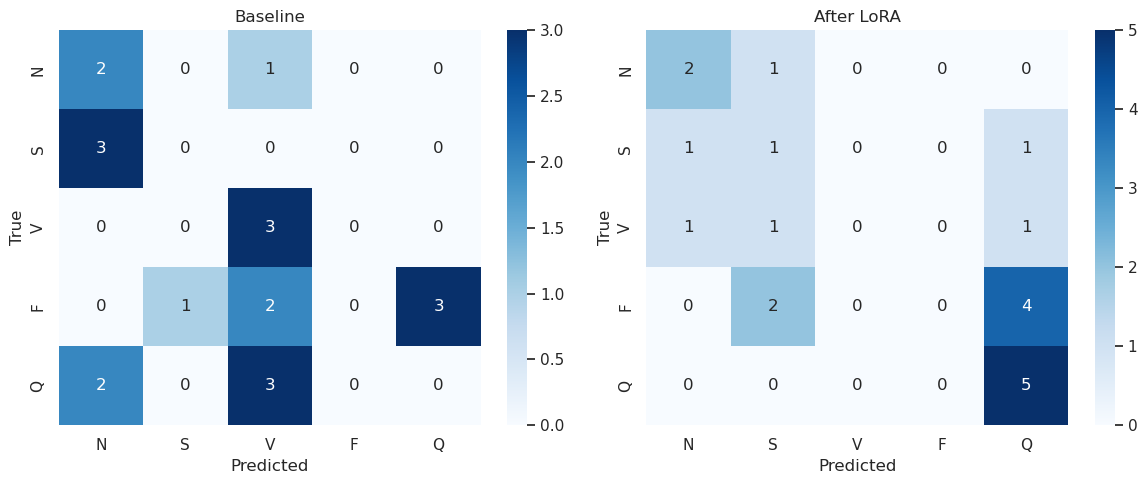

In [20]:
# Free memory and reload the baseline
del gemma_lm
gc.collect()

#Evaluation of the baseline
gemma_baseline = load_gemma()
acc_base, cm_base, fmt_base, results_base = evaluate(gemma_baseline, eval_pairs)

# Side-by-side comparison
labels = list("NSVFQ")
print(f"\nBaseline accuracy        : {acc_base:.1%}")
print(f"LoRA-tuned accuracy      : {acc_lora:.1%}")
print(f"Baseline format compliance: {fmt_base:.1%}")
print(f"LoRA format compliance    : {fmt_lora:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in zip(axes, [cm_base, cm_lora], ["Baseline", "After LoRA"]):
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels,
                cmap='Blues', ax=ax)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

# References
 - HuggingFace: https://huggingface.co/
 - Multimodal and Agentic with Gemma4: https://www.kaggle.com/code/prasadsachin/multimodal-and-agentic-with-gemma4-in-keras-hub
 - Keras guide on Transfer learning & Fine-tuning: https://keras.io/guides/transfer_learning/
 - Hu et al. *LoRA: Low-Rank Adaptation of Large Language Models*. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
 - Keras Hub Gemma documentation: https://keras.io/api/keras_hub/models/gemma/
 - Keras guide on LoRA and QLoRA: https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/